In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/Users/6ixbio/Downloads/revops-analytics-portfolio/06-analytics-pipeline")
EXPORT_DIR = BASE_DIR / "data" / "exports"

monthly_revenue = pd.read_csv(EXPORT_DIR / "monthly_revenue.csv", parse_dates=["month"])
monthly_margin = pd.read_csv(EXPORT_DIR / "monthly_margin.csv", parse_dates=["month"])
pipeline_stage = pd.read_csv(EXPORT_DIR / "pipeline_stage.csv")

print("monthly_revenue:", monthly_revenue.shape)
print("monthly_margin:", monthly_margin.shape)
print("pipeline_stage:", pipeline_stage.shape)

monthly_revenue: (27, 4)
monthly_margin: (27, 5)
pipeline_stage: (6, 4)


In [ ]:
## 1. Data Quality and Schema Validation

Before interpreting KPI outputs, validate structure, completeness, and data types.  
This ensures downstream metrics are analytically trustworthy.

In [3]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    profile = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isna().sum().values,
        "null_pct": (df.isna().mean() * 100).round(2).values,
        "distinct_count": df.nunique(dropna=False).values,
    })
    profile.insert(0, "dataset", name)
    return profile

dq_profile = pd.concat([
    profile_dataframe(monthly_revenue, "monthly_revenue"),
    profile_dataframe(monthly_margin, "monthly_margin"),
    profile_dataframe(pipeline_stage, "pipeline_stage"),
], ignore_index=True)

dq_profile

,dataset,column,dtype,null_count,null_pct,distinct_count
0,monthly_revenue,month,datetime64[ns],0,0.0,27
1,monthly_revenue,total_revenue,float64,0,0.0,27
2,monthly_revenue,total_orders,int64,0,0.0,25
3,monthly_revenue,aov,float64,0,0.0,27
4,monthly_margin,month,datetime64[ns],0,0.0,27
5,monthly_margin,sales,float64,0,0.0,27
6,monthly_margin,cogs,float64,0,0.0,27
7,monthly_margin,gross_margin,float64,0,0.0,27
8,monthly_margin,gross_margin_pct,float64,0,0.0,27
9,pipeline_stage,stage,object,0,0.0,6


In [4]:
expected_columns = {
    "monthly_revenue": {"month", "total_revenue", "total_orders", "aov"},
    "monthly_margin": {"month", "sales", "cogs", "gross_margin", "gross_margin_pct"},
    "pipeline_stage": {"stage", "opp_count", "pipeline_amount", "avg_probability"},
}

actual_columns = {
    "monthly_revenue": set(monthly_revenue.columns),
    "monthly_margin": set(monthly_margin.columns),
    "pipeline_stage": set(pipeline_stage.columns),
}

schema_check = []
for dataset_name, expected in expected_columns.items():
    actual = actual_columns[dataset_name]
    schema_check.append({
        "dataset": dataset_name,
        "missing_columns": sorted(list(expected - actual)),
        "unexpected_columns": sorted(list(actual - expected)),
        "schema_valid": expected == actual,
    })

schema_check_df = pd.DataFrame(schema_check)
schema_check_df

,dataset,missing_columns,unexpected_columns,schema_valid
0,monthly_revenue,[],[],True
1,monthly_margin,[],[],True
2,pipeline_stage,[],[],True


In [ ]:
## 2. Standardization

Normalize sort order and enforce metric consistency before trend analysis.

In [5]:
monthly_revenue = monthly_revenue.sort_values("month").reset_index(drop=True).copy()
monthly_margin = monthly_margin.sort_values("month").reset_index(drop=True).copy()
pipeline_stage = pipeline_stage.sort_values("pipeline_amount", ascending=False).reset_index(drop=True).copy()

# Defensive numeric enforcement
revenue_numeric_cols = ["total_revenue", "total_orders", "aov"]
margin_numeric_cols = ["sales", "cogs", "gross_margin", "gross_margin_pct"]
pipeline_numeric_cols = ["opp_count", "pipeline_amount", "avg_probability"]

for col in revenue_numeric_cols:
    monthly_revenue[col] = pd.to_numeric(monthly_revenue[col], errors="coerce")

for col in margin_numeric_cols:
    monthly_margin[col] = pd.to_numeric(monthly_margin[col], errors="coerce")

for col in pipeline_numeric_cols:
    pipeline_stage[col] = pd.to_numeric(pipeline_stage[col], errors="coerce")

display(monthly_revenue.head())
display(monthly_margin.head())
display(pipeline_stage.head())

,month,total_revenue,total_orders,aov
0,2024-01-01,1613041.48,468,3446.669829
1,2024-02-01,1363754.25,375,3636.678000
2,2024-03-01,1525922.47,436,3499.822179
3,2024-04-01,1535486.31,435,3529.853586
4,2024-05-01,1446877.92,425,3404.418635


,month,sales,cogs,gross_margin,gross_margin_pct
0,2024-01-01,1605278.01,1058730.58,546547.43,0.340469
1,2024-02-01,1352870.33,902038.56,450831.77,0.333241
2,2024-03-01,1523448.34,1019251.73,504196.61,0.330957
3,2024-04-01,1532861.59,1014499.41,518362.18,0.338166
4,2024-05-01,1440334.90,959170.92,481163.98,0.334064


,stage,opp_count,pipeline_amount,avg_probability
0,Discovery,465,1.173567e+08,25.0
1,Solutioning,463,1.150223e+08,45.0
2,Negotiation,475,1.148484e+08,70.0
3,Closed Won,403,1.087691e+08,100.0
4,Prospecting,353,8.464100e+07,10.0


In [ ]:
## 3. Revenue Trend Engineering

Build period-over-period and rolling metrics to support executive interpretation.

In [6]:
monthly_revenue["revenue_mom_pct"] = monthly_revenue["total_revenue"].pct_change()
monthly_revenue["orders_mom_pct"] = monthly_revenue["total_orders"].pct_change()
monthly_revenue["aov_mom_pct"] = monthly_revenue["aov"].pct_change()

monthly_revenue["revenue_3m_rolling"] = monthly_revenue["total_revenue"].rolling(window=3, min_periods=1).mean()
monthly_revenue["orders_3m_rolling"] = monthly_revenue["total_orders"].rolling(window=3, min_periods=1).mean()
monthly_revenue["aov_3m_rolling"] = monthly_revenue["aov"].rolling(window=3, min_periods=1).mean()

monthly_revenue["revenue_index_100"] = (monthly_revenue["total_revenue"] / monthly_revenue["total_revenue"].iloc[0]) * 100
monthly_revenue["orders_index_100"] = (monthly_revenue["total_orders"] / monthly_revenue["total_orders"].iloc[0]) * 100

monthly_revenue.round(4).head(10)

,month,total_revenue,total_orders,aov,revenue_mom_pct,orders_mom_pct,aov_mom_pct,revenue_3m_rolling,orders_3m_rolling,aov_3m_rolling,revenue_index_100,orders_index_100
0,2024-01-01,1613041.48,468,3446.6698,NaN,NaN,NaN,1.613041e+06,468.0000,3446.6698,100.0000,100.0000
1,2024-02-01,1363754.25,375,3636.6780,-0.1545,-0.1987,0.0551,1.488398e+06,421.5000,3541.6739,84.5455,80.1282
2,2024-03-01,1525922.47,436,3499.8222,0.1189,0.1627,-0.0376,1.500906e+06,426.3333,3527.7233,94.5991,93.1624
3,2024-04-01,1535486.31,435,3529.8536,0.0063,-0.0023,0.0086,1.475054e+06,415.3333,3555.4513,95.1920,92.9487
4,2024-05-01,1446877.92,425,3404.4186,-0.0577,-0.0230,-0.0355,1.502762e+06,432.0000,3478.0315,89.6987,90.8120
5,2024-06-01,1509989.70,424,3561.2965,0.0436,-0.0024,0.0461,1.497451e+06,428.0000,3498.5229,93.6113,90.5983
6,2024-07-01,1669951.20,459,3638.2379,0.1059,0.0825,0.0216,1.542273e+06,436.0000,3534.6510,103.5281,98.0769
7,2024-08-01,1474686.26,444,3321.3655,-0.1169,-0.0327,-0.0871,1.551542e+06,442.3333,3506.9666,91.4227,94.8718
8,2024-09-01,1317999.61,410,3214.6332,-0.1063,-0.0766,-0.0321,1.487546e+06,437.6667,3391.4122,81.7090,87.6068
9,2024-10-01,1375932.49,417,3299.5983,0.0440,0.0171,0.0264,1.389539e+06,423.6667,3278.5323,85.3005,89.1026


In [ ]:
## 4. Revenue Performance Summary

In [7]:
revenue_summary = pd.DataFrame([{
    "months_observed": int(len(monthly_revenue)),
    "total_revenue_sum": monthly_revenue["total_revenue"].sum(),
    "avg_monthly_revenue": monthly_revenue["total_revenue"].mean(),
    "max_monthly_revenue": monthly_revenue["total_revenue"].max(),
    "min_monthly_revenue": monthly_revenue["total_revenue"].min(),
    "avg_monthly_orders": monthly_revenue["total_orders"].mean(),
    "avg_aov": monthly_revenue["aov"].mean(),
    "latest_month_revenue": monthly_revenue["total_revenue"].iloc[-1],
    "latest_month_orders": monthly_revenue["total_orders"].iloc[-1],
    "latest_month_aov": monthly_revenue["aov"].iloc[-1],
}])

revenue_summary.T.rename(columns={0: "value"})

,value
months_observed,2.700000e+01
total_revenue_sum,3.879571e+07
avg_monthly_revenue,1.436878e+06
max_monthly_revenue,1.669951e+06
min_monthly_revenue,5.630563e+04
avg_monthly_orders,4.126667e+02
avg_aov,3.445801e+03
latest_month_revenue,5.630563e+04
latest_month_orders,2.300000e+01
latest_month_aov,2.448071e+03


In [8]:
top_revenue_months = (
    monthly_revenue[["month", "total_revenue", "total_orders", "aov"]]
    .sort_values("total_revenue", ascending=False)
    .head(5)
)

top_revenue_months

,month,total_revenue,total_orders,aov
6,2024-07-01,1669951.20,459,3638.237908
14,2025-03-01,1664765.20,473,3519.588161
0,2024-01-01,1613041.48,468,3446.669829
12,2025-01-01,1590409.95,452,3518.606084
19,2025-08-01,1558559.53,434,3591.150991


In [ ]:
## 5. Margin Performance Engineering

Assess stability, volatility, and tolerance bands for gross margin performance.

In [9]:
monthly_margin["margin_mom_pct"] = monthly_margin["gross_margin_pct"].pct_change()
monthly_margin["margin_3m_rolling"] = monthly_margin["gross_margin_pct"].rolling(window=3, min_periods=1).mean()

margin_mean = monthly_margin["gross_margin_pct"].mean()
margin_std = monthly_margin["gross_margin_pct"].std()

monthly_margin["margin_lower_band"] = margin_mean - margin_std
monthly_margin["margin_upper_band"] = margin_mean + margin_std

monthly_margin["margin_status"] = np.select(
    [
        monthly_margin["gross_margin_pct"] < monthly_margin["margin_lower_band"],
        monthly_margin["gross_margin_pct"] > monthly_margin["margin_upper_band"],
    ],
    [
        "Below Expected Range",
        "Above Expected Range",
    ],
    default="Within Expected Range"
)

monthly_margin[[
    "month",
    "gross_margin_pct",
    "margin_3m_rolling",
    "margin_lower_band",
    "margin_upper_band",
    "margin_status"
]].tail(12)

,month,gross_margin_pct,margin_3m_rolling,margin_lower_band,margin_upper_band,margin_status
15,2025-04-01,0.334670,0.335952,0.331693,0.339196,Within Expected Range
16,2025-05-01,0.334320,0.334275,0.331693,0.339196,Within Expected Range
17,2025-06-01,0.339451,0.336147,0.331693,0.339196,Above Expected Range
18,2025-07-01,0.340888,0.338220,0.331693,0.339196,Above Expected Range
19,2025-08-01,0.337701,0.339346,0.331693,0.339196,Within Expected Range
20,2025-09-01,0.335410,0.338000,0.331693,0.339196,Within Expected Range
21,2025-10-01,0.335303,0.336138,0.331693,0.339196,Within Expected Range
22,2025-11-01,0.337008,0.335907,0.331693,0.339196,Within Expected Range
23,2025-12-01,0.335380,0.335897,0.331693,0.339196,Within Expected Range
24,2026-01-01,0.336549,0.336312,0.331693,0.339196,Within Expected Range


In [10]:
margin_summary = pd.DataFrame([{
    "avg_margin_pct": margin_mean,
    "margin_std_dev": margin_std,
    "max_margin_pct": monthly_margin["gross_margin_pct"].max(),
    "min_margin_pct": monthly_margin["gross_margin_pct"].min(),
    "months_below_expected": int((monthly_margin["margin_status"] == "Below Expected Range").sum()),
    "months_above_expected": int((monthly_margin["margin_status"] == "Above Expected Range").sum()),
}])

margin_summary.T.rename(columns={0: "value"})

,value
avg_margin_pct,0.335444
margin_std_dev,0.003751
max_margin_pct,0.343315
min_margin_pct,0.326322
months_below_expected,4.000000
months_above_expected,5.000000


In [ ]:
## 6. Pipeline Structure and Forecast Quality

Evaluate funnel concentration and weighted commercial outlook.

In [11]:
pipeline_stage["pipeline_share_pct"] = pipeline_stage["pipeline_amount"] / pipeline_stage["pipeline_amount"].sum()
pipeline_stage["weighted_pipeline_amount"] = pipeline_stage["pipeline_amount"] * (pipeline_stage["avg_probability"] / 100)
pipeline_stage["opp_share_pct"] = pipeline_stage["opp_count"] / pipeline_stage["opp_count"].sum()

pipeline_stage

,stage,opp_count,pipeline_amount,avg_probability,pipeline_share_pct,weighted_pipeline_amount,opp_share_pct
0,Discovery,465,1.173567e+08,25.0,0.194904,2.933917e+07,0.193750
1,Solutioning,463,1.150223e+08,45.0,0.191027,5.176005e+07,0.192917
2,Negotiation,475,1.148484e+08,70.0,0.190738,8.039386e+07,0.197917
3,Closed Won,403,1.087691e+08,100.0,0.180642,1.087691e+08,0.167917
4,Prospecting,353,8.464100e+07,10.0,0.140570,8.464100e+06,0.147083
5,Closed Lost,241,6.148878e+07,0.0,0.102119,0.000000e+00,0.100417


In [12]:
pipeline_summary = pd.DataFrame([{
    "total_pipeline_amount": pipeline_stage["pipeline_amount"].sum(),
    "total_weighted_pipeline": pipeline_stage["weighted_pipeline_amount"].sum(),
    "largest_stage": pipeline_stage.loc[pipeline_stage["pipeline_amount"].idxmax(), "stage"],
    "largest_stage_amount": pipeline_stage["pipeline_amount"].max(),
    "largest_stage_share_pct": pipeline_stage["pipeline_share_pct"].max(),
    "avg_stage_probability": pipeline_stage["avg_probability"].mean(),
}])

pipeline_summary.T.rename(columns={0: "value"})

,value
total_pipeline_amount,602126236.82
total_weighted_pipeline,278726259.274
largest_stage,Discovery
largest_stage_amount,117356664.16
largest_stage_share_pct,0.194904
avg_stage_probability,41.666667


In [ ]:
## 7. Exception Reporting

Highlight periods and stages requiring leadership attention.

In [13]:
revenue_alerts = monthly_revenue.loc[
    monthly_revenue["revenue_mom_pct"].abs() > 0.10,
    ["month", "total_revenue", "revenue_mom_pct", "total_orders", "orders_mom_pct", "aov"]
].copy()

margin_alerts = monthly_margin.loc[
    monthly_margin["margin_status"] != "Within Expected Range",
    ["month", "gross_margin_pct", "margin_status"]
].copy()

pipeline_alerts = pipeline_stage.loc[
    pipeline_stage["pipeline_share_pct"] > 0.35,
    ["stage", "pipeline_amount", "pipeline_share_pct", "avg_probability"]
].copy()

print("Revenue alerts")
display(revenue_alerts)

print("Margin alerts")
display(margin_alerts)

print("Pipeline concentration alerts")
display(pipeline_alerts)

Revenue alerts


,month,total_revenue,revenue_mom_pct,total_orders,orders_mom_pct,aov
1,2024-02-01,1363754.25,-0.154545,375,-0.198718,3636.678000
2,2024-03-01,1525922.47,0.118913,436,0.162667,3499.822179
6,2024-07-01,1669951.20,0.105935,459,0.082547,3638.237908
7,2024-08-01,1474686.26,-0.116929,444,-0.032680,3321.365450
8,2024-09-01,1317999.61,-0.106251,410,-0.076577,3214.633195
15,2025-04-01,1467379.29,-0.118567,416,-0.120507,3527.354062
20,2025-09-01,1353084.37,-0.131837,407,-0.062212,3324.531622
21,2025-10-01,1557031.56,0.150728,447,0.098280,3483.292081
22,2025-11-01,1398754.51,-0.101653,411,-0.080537,3403.295645
26,2026-03-01,56305.63,-0.961699,23,-0.942356,2448.070870


Margin alerts


,month,gross_margin_pct,margin_status
0,2024-01-01,0.340469,Above Expected Range
2,2024-03-01,0.330957,Below Expected Range
5,2024-06-01,0.330551,Below Expected Range
11,2024-12-01,0.329684,Below Expected Range
13,2025-02-01,0.339351,Above Expected Range
17,2025-06-01,0.339451,Above Expected Range
18,2025-07-01,0.340888,Above Expected Range
25,2026-02-01,0.343315,Above Expected Range
26,2026-03-01,0.326322,Below Expected Range


Pipeline concentration alerts


,stage,pipeline_amount,pipeline_share_pct,avg_probability


In [ ]:
## 8. Analytical Visuals

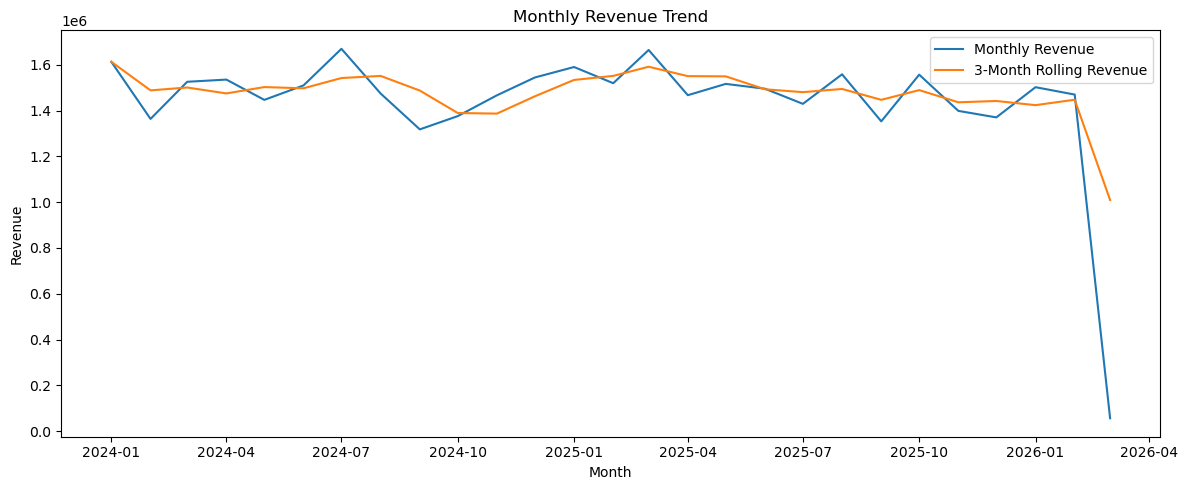

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["month"], monthly_revenue["total_revenue"], label="Monthly Revenue")
plt.plot(monthly_revenue["month"], monthly_revenue["revenue_3m_rolling"], label="3-Month Rolling Revenue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

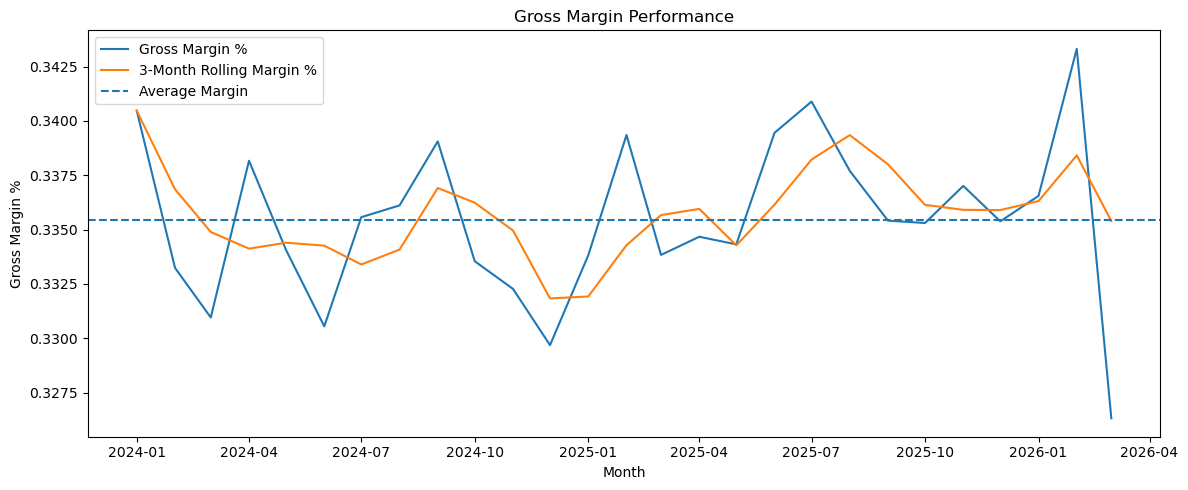

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_margin["month"], monthly_margin["gross_margin_pct"], label="Gross Margin %")
plt.plot(monthly_margin["month"], monthly_margin["margin_3m_rolling"], label="3-Month Rolling Margin %")
plt.axhline(margin_mean, linestyle="--", label="Average Margin")
plt.title("Gross Margin Performance")
plt.xlabel("Month")
plt.ylabel("Gross Margin %")
plt.legend()
plt.tight_layout()
plt.show()

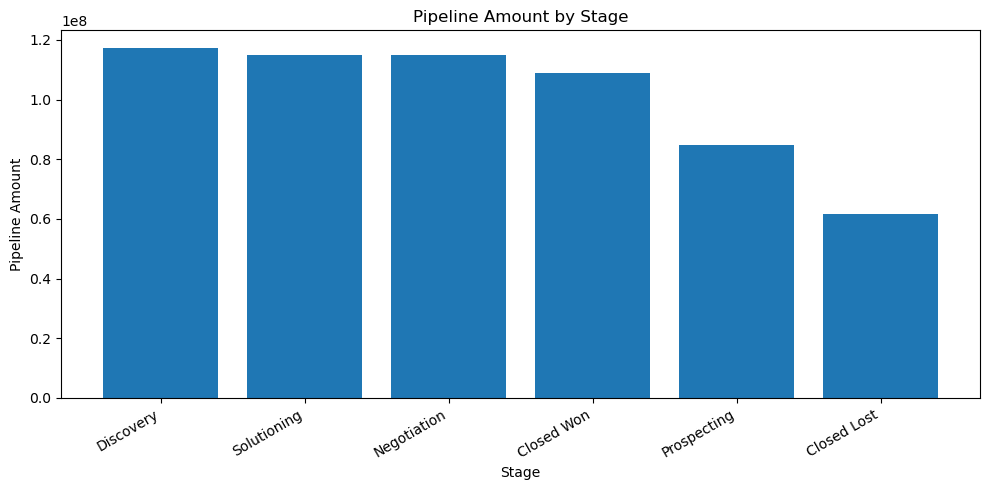

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(pipeline_stage["stage"], pipeline_stage["pipeline_amount"])
plt.title("Pipeline Amount by Stage")
plt.xlabel("Stage")
plt.ylabel("Pipeline Amount")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
## 9. Executive Insights

In [17]:
top_revenue_month = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmax()]
low_revenue_month = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmin()]
top_margin_month = monthly_margin.loc[monthly_margin["gross_margin_pct"].idxmax()]
low_margin_month = monthly_margin.loc[monthly_margin["gross_margin_pct"].idxmin()]
top_pipeline_stage = pipeline_stage.loc[pipeline_stage["pipeline_amount"].idxmax()]

insights = [
    f"Peak monthly revenue occurred in {top_revenue_month['month']:%Y-%m} at ${top_revenue_month['total_revenue']:,.0f}, establishing the upper bound of observed commercial performance.",
    f"Lowest monthly revenue occurred in {low_revenue_month['month']:%Y-%m} at ${low_revenue_month['total_revenue']:,.0f}, indicating a material spread across periods that leadership should contextualize against seasonality or campaign timing.",
    f"Average order value across the observed window was ${monthly_revenue['aov'].mean():,.0f}, suggesting a relatively high-value transaction profile consistent with larger basket or B2B-style order behavior.",
    f"Gross margin averaged {monthly_margin['gross_margin_pct'].mean():.1%} with relatively controlled volatility, indicating pricing discipline and cost containment are broadly stable.",
    f"The strongest margin month was {top_margin_month['month']:%Y-%m} at {top_margin_month['gross_margin_pct']:.1%}, while the weakest was {low_margin_month['month']:%Y-%m} at {low_margin_month['gross_margin_pct']:.1%}.",
    f"Pipeline concentration is highest in the {top_pipeline_stage['stage']} stage at ${top_pipeline_stage['pipeline_amount']:,.0f}, which implies forecast sensitivity to a single funnel segment.",
    f"Weighted pipeline totals approximately ${pipeline_stage['weighted_pipeline_amount'].sum():,.0f}, providing a more realistic near-term commercial view than unweighted pipeline volume alone.",
]
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Peak monthly revenue occurred in 2024-07 at $1,669,951, establishing the upper bound of observed commercial performance.
2. Lowest monthly revenue occurred in 2026-03 at $56,306, indicating a material spread across periods that leadership should contextualize against seasonality or campaign timing.
3. Average order value across the observed window was $3,446, suggesting a relatively high-value transaction profile consistent with larger basket or B2B-style order behavior.
4. Gross margin averaged 33.5% with relatively controlled volatility, indicating pricing discipline and cost containment are broadly stable.
5. The strongest margin month was 2026-02 at 34.3%, while the weakest was 2026-03 at 32.6%.
6. Pipeline concentration is highest in the Discovery stage at $117,356,664, which implies forecast sensitivity to a single funnel segment.
7. Weighted pipeline totals approximately $278,726,259, providing a more realistic near-term commercial view than unweighted pipeline volume alone.


In [ ]:
## 10. Export Analytical Outputs

In [18]:
insight_df = pd.DataFrame({"insight": insights})
insight_path = BASE_DIR / "docs" / "executive_insights.csv"
insight_df.to_csv(insight_path, index=False)

analytic_summary_path = BASE_DIR / "docs" / "analytic_summary.xlsx"
with pd.ExcelWriter(analytic_summary_path, engine="openpyxl") as writer:
    dq_profile.to_excel(writer, sheet_name="data_quality_profile", index=False)
    schema_check_df.to_excel(writer, sheet_name="schema_check", index=False)
    monthly_revenue.to_excel(writer, sheet_name="monthly_revenue", index=False)
    monthly_margin.to_excel(writer, sheet_name="monthly_margin", index=False)
    pipeline_stage.to_excel(writer, sheet_name="pipeline_stage", index=False)
    revenue_alerts.to_excel(writer, sheet_name="revenue_alerts", index=False)
    margin_alerts.to_excel(writer, sheet_name="margin_alerts", index=False)
    pipeline_alerts.to_excel(writer, sheet_name="pipeline_alerts", index=False)

print("Saved:")
print("-", insight_path)
print("-", analytic_summary_path)

Saved:
- /Users/6ixbio/Downloads/revops-analytics-portfolio/06-analytics-pipeline/docs/executive_insights.csv
- /Users/6ixbio/Downloads/revops-analytics-portfolio/06-analytics-pipeline/docs/analytic_summary.xlsx


In [ ]:
## 11. Conclusion

This notebook demonstrates an end-to-end Director-level analytics workflow:

- validated KPI data inputs
- engineered trend and stability metrics
- quantified pipeline concentration and weighted forecast value
- identified management exceptions
- translated outputs into executive-ready business insights

Together with the ETL scripts, DuckDB warehouse, and Tableau layer, this project represents a complete analytics delivery pattern suitable for revenue operations, executive reporting, and decision support consulting.